In [60]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

In [61]:
# Load the Sleep and Lifestyle study data
data = pd.read_csv("./data/Sleep_health_and_lifestyle_dataset.csv")
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## TODO: (repeat this workflow removing half of the features)
- pick dimension reduction method to cut # features in half 
    - Mutual Infomation 
- visualiza k-fold  cv results from each model
- report best hyper params selected for each model
- train each model using best hyper param & report train & test performance
- repeat above steps for multiclass classification models
- **see if CUDA library will enable hardware acceleration for faster training**

In [62]:
# Split blood pressure into the systolic and diastolic blood pressures
data[["Systolic Blood Pressure", "Diastolic Blood Pressure"]] = data["Blood Pressure"].str.split('/', expand=True)
data[["Systolic Blood Pressure", "Diastolic Blood Pressure"]] = data[["Systolic Blood Pressure", "Diastolic Blood Pressure"]].astype(int)
data = data.drop(columns=["Blood Pressure"])

# Define different column types and separate the data into features and targets
cat_columns = ["Occupation", "BMI Category", "Sleep Disorder", "Gender"]
num_columns = ["Age", "Sleep Duration", "Physical Activity Level", "Heart Rate", "Daily Steps", "Systolic Blood Pressure", "Diastolic Blood Pressure"]
features = cat_columns + num_columns

X, sleep_quality, stress = data[features], data["Quality of Sleep"], data["Stress Level"]

In [63]:
# Convert stress to be a binary variable for binary classification (0 represents low stress, 1 represents high stress)
stress = np.where(stress > 5, 1, 0)

In [64]:
# Preform the train-test split
X_train, X_test, stress_train, stress_test, quality_train, quality_test = train_test_split(X, stress, sleep_quality, test_size = 0.1, random_state = 6)

In [65]:
# NOTE: >50% the observations are missing in the "Sleep Disorder" column,
# it is candidate for being dropped, as it likely already has weak predictive signal (due to missingness)
# and dropping missing rows would impact all of the models downstream as we'd be loosing ~half the dataset


print(f"{X_train.isna().sum()}")

X_train = X_train.drop(columns=['Sleep Disorder'])
X_test = X_test.drop(columns=['Sleep Disorder'])
cat_columns =["Occupation", "BMI Category", "Gender"] # remove "Sleep Disorder"
features = cat_columns + num_columns

Occupation                    0
BMI Category                  0
Sleep Disorder              192
Gender                        0
Age                           0
Sleep Duration                0
Physical Activity Level       0
Heart Rate                    0
Daily Steps                   0
Systolic Blood Pressure       0
Diastolic Blood Pressure      0
dtype: int64


# Feature Selection Approach: Mutual Information

Measures how much knowing a feature reduces uncertainty in the response (entropy)

Entropy for a classification target is:

$H(Y) = -\sum P(y)logP(y)$ 

where higher entropy H(Y) = more uncertainty (worse)

Mutual Information Formula:

$I(X;Y) = H(Y) - H(Y|X)$

this measures reduction in uncertainty about Y after knowing feature X, or how much knowing one feature recudes uncertainty in the other (response)


In [66]:
# NOTE: sklearn's implementation of MI expects ALL NUMERIC FEATURES,
# so allencoding must be done before hand
# MI should also ONLY be calculated on the TRAINING set to avoid data leakage

#NOTE: encoding done here is purely for feature scoring; then will reuse original workflow
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif

mi_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_columns),
        ('cat', OrdinalEncoder(), cat_columns)
    ]
)

X_train_mi = mi_preprocessor.fit_transform(X_train)

mi_scores_binary = mutual_info_classif(X_train_mi, stress_train)
mi_scores_multi = mutual_info_classif(X_train_mi, quality_train)

#put features & scores in pandas df for easy filtering
mi_binary_df = pd.DataFrame({
    "Feature": features,
    "MI Score": mi_scores_binary
}).sort_values(by="MI Score", ascending=False)

mi_multi_df = pd.DataFrame({
    "Feature": features,
    "MI Score": mi_scores_multi
}).sort_values(by="MI Score", ascending=False)

print(mi_binary_df)
print(mi_multi_df)

                    Feature  MI Score
1              BMI Category  0.429448
3                       Age  0.426227
0                Occupation  0.344950
7               Daily Steps  0.342227
4            Sleep Duration  0.141880
2                    Gender  0.136691
5   Physical Activity Level  0.118059
8   Systolic Blood Pressure  0.075259
6                Heart Rate  0.068676
9  Diastolic Blood Pressure  0.018899
                    Feature  MI Score
1              BMI Category  1.140386
0                Occupation  0.926350
3                       Age  0.727954
4            Sleep Duration  0.685481
2                    Gender  0.681460
7               Daily Steps  0.678272
5   Physical Activity Level  0.575812
6                Heart Rate  0.529523
8   Systolic Blood Pressure  0.242682
9  Diastolic Blood Pressure  0.076582


In [67]:
# filter to top half of features by MI score
top_features_binary = mi_binary_df["Feature"].iloc[:len(features)//2].tolist()
top_features_multi = mi_multi_df["Feature"].iloc[:len(features)//2].tolist()

print(f"Top Binary Features:\n{top_features_binary}\n\nTop Multiclass Features:\n{top_features_multi}")

Top Binary Features:
['BMI Category', 'Age', 'Occupation', 'Daily Steps', 'Sleep Duration']

Top Multiclass Features:
['BMI Category', 'Occupation', 'Age', 'Sleep Duration', 'Gender']


In [68]:
all_cat_columns = ["Occupation", "BMI Category", "Gender"]
all_num_columns = ["Age", "Sleep Duration", "Physical Activity Level", "Heart Rate", "Daily Steps", "Systolic Blood Pressure", "Diastolic Blood Pressure"]

def make_preprocessor(selected_features):
    selected_num = [col for col in selected_features if col in all_num_columns]
    selected_cat = [col for col in selected_features if col in all_cat_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), selected_num),
            ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), selected_cat)
        ]
    )

    return preprocessor

def make_cat_preprocessor(selected_features):
    selected_cat = [col for col in selected_features if col in all_cat_columns]

    cat_preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), selected_cat)
        ]
    )

    return cat_preprocessor

binary_preprocessor = make_preprocessor(top_features_binary)
multi_preprocessor = make_preprocessor(top_features_multi)

binary_cat_preprocessor = make_cat_preprocessor(top_features_binary)
multi_cat_preprocessor = make_cat_preprocessor(top_features_multi)

X_train_binary = X_train[top_features_binary]
X_test_binary = X_test[top_features_binary]


X_train_multi = X_train[top_features_multi]
X_test_multi = X_test[top_features_multi]

X_train_binary_transformed = binary_preprocessor.fit_transform(X_train_binary)
X_test_binary_transformed = binary_preprocessor.transform(X_test_binary)

X_train_multi_transformed = multi_preprocessor.fit_transform(X_train_multi)
X_test_multi_transformed = multi_preprocessor.transform(X_test_multi)

X_train_cat_transformed_binary = binary_cat_preprocessor.fit_transform(X_train_binary)
X_test_cat_transformed_binary = binary_cat_preprocessor.transform(X_test_binary)

X_train_cat_transformed_multi = multi_cat_preprocessor.fit_transform(X_train_multi)
X_test_cat_transformed_multi = multi_cat_preprocessor.transform(X_test_multi)

In [69]:
# Tune the k value of the kNN classifier using 5-fold cross validation
knn_param_grid = {
    'n_neighbors': [1, 2, 3, 4, 5, 10, 20]
}
search_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5)
search_knn.fit(X_train_binary_transformed, stress_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter in

In [70]:
# Fit a kNN classifier with the best value of k
knn_classifier = KNeighborsClassifier(n_neighbors = search_knn.best_params_['n_neighbors'])
knn_classifier.fit(X_train_binary_transformed, stress_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [71]:
# Make predictions on the test set and report the prediction accuracy of the kNN model
stress_pred_knn = knn_classifier.predict(X_test_binary_transformed)
print(knn_classifier.score(X_test_binary_transformed, stress_test))
knn_accuracy = 1 - (np.sum(np.where(stress_pred_knn != stress_test, 1, 0)) / np.size(stress_test))
print(knn_accuracy)

1.0
1.0


In [72]:
# Fit and test a decision tree classifier with a tuned max_depth
dt_param_grid = {
    'max_depth': [1, 2, 3, 5, 7, 10, None]
}
search_dt = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5)
search_dt.fit(X_train_binary_transformed, stress_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter in

In [73]:
dt_classifier = DecisionTreeClassifier(max_depth = search_dt.best_params_['max_depth'])
dt_classifier.fit(X_train_binary_transformed, stress_train)
stress_pred_dt = dt_classifier.predict(X_test_binary_transformed)
print(dt_classifier.score(X_test_binary_transformed, stress_test))
dt_accuracy = 1 - (np.sum(np.where(stress_pred_dt != stress_test, 1, 0)) / np.size(stress_test))
print(dt_accuracy)

0.9736842105263158
0.9736842105263158


In [74]:
# Fit and test a SVM classifier with a tuned value of C and kernel chosen from linear, polynomial, and gaussian RBF using 5-fold cross validation
svm_param_grid = {
    'C': [0.1, 1, 10, 50, 100, 500, 1000],
    'kernel': ['linear', 'poly', 'rbf']
}
search_svm = GridSearchCV(SVC(), svm_param_grid, cv=5)
search_svm.fit(X_train_binary_transformed, stress_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate pa

In [75]:
svm_classifier = SVC(C = search_svm.best_params_['C'], kernel = search_svm.best_params_['kernel'])
svm_classifier.fit(X_train_binary_transformed, stress_train)
stress_pred_svm = svm_classifier.predict(X_test_binary_transformed)
print(svm_classifier.score(X_test_binary_transformed, stress_test))
svm_accuracy = 1 - (np.sum(np.where(stress_pred_svm != stress_test, 1, 0)) / np.size(stress_test))
print(svm_accuracy)

1.0
1.0


In [76]:
# Fit and test a random forest classifier with a tuned max depth using 5-fold cross validation
# Max depth choices are higher for random forest than for a single decision tree to take advantage of lower bias in bagging
rf_param_grid = {
    'max_depth': [3, 5, 7, 10, 13, None]
}
search_rf = GridSearchCV(RandomForestClassifier(n_estimators = 200, bootstrap = True), rf_param_grid, cv=5)
search_rf.fit(X_train_binary_transformed, stress_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...stimators=200)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [77]:
rf_classifier = RandomForestClassifier(max_depth = search_rf.best_params_['max_depth'], n_estimators = 200, bootstrap = True)
rf_classifier.fit(X_train_binary_transformed, stress_train)
stress_pred_rf = rf_classifier.predict(X_test_binary_transformed)
print(rf_classifier.score(X_test_binary_transformed, stress_test))
rf_accuracy = 1 - (np.sum(np.where(stress_pred_rf != stress_test, 1, 0)) / np.size(stress_test))
print(rf_accuracy)

0.9473684210526315
0.9473684210526316


In [78]:
# Fit and test a naive Bayes classifier with a tuned additive smoothing parameter using 5-fold cross validation
nb_param_grid = {
    'alpha': [1, 2, 3]
}
search_nb = GridSearchCV(CategoricalNB(min_categories=2), nb_param_grid, cv=5)
search_nb.fit(X_train_cat_transformed_binary.toarray(), stress_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CategoricalNB..._categories=2)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter 

In [79]:
nb_classifier = CategoricalNB(min_categories = 2, alpha = search_nb.best_params_['alpha'])
nb_classifier.fit(X_train_cat_transformed_binary.toarray(), stress_train)
stress_pred_nb = nb_classifier.predict(X_test_cat_transformed_binary.toarray())
print(nb_classifier.score(X_test_cat_transformed_binary.toarray(), stress_test))
nb_accuracy = 1 - (np.sum(np.where(stress_pred_nb != stress_test, 1, 0)) / np.size(stress_test))
print(nb_accuracy)

0.7894736842105263
0.7894736842105263


In [80]:
# Fit and test an artificial neural network with a tuned number of hidden layer nodes, and choices of activation function and max iterations made using 5-fold cross validation
# Note: This code cell takes a long time to run
ann_param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (20,), (50,), (100,), (150,)],
    'max_iter': [2000, 5000, 10000, 20000],
    'activation': ['logistic', 'tanh', 'relu']
}
search_ann = GridSearchCV(MLPClassifier(), ann_param_grid, cv=5)
search_ann.fit(X_train_binary_transformed, stress_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['logistic', 'tanh', ...], 'hidden_layer_sizes': [(5,), (10,), ...], 'max_iter': [2000, 5000, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [81]:
ann_classifier = MLPClassifier(hidden_layer_sizes = search_ann.best_params_['hidden_layer_sizes'], max_iter = search_ann.best_params_['max_iter'], activation = search_ann.best_params_['activation'])
ann_classifier.fit(X_train_binary_transformed, stress_train)
stress_pred_ann = ann_classifier.predict(X_test_binary_transformed)
print(ann_classifier.score(X_test_binary_transformed, stress_test))
ann_accuracy = 1 - (np.sum(np.where(stress_pred_ann != stress_test, 1, 0)) / np.size(stress_test))
print(ann_accuracy)

0.9210526315789473
0.9210526315789473


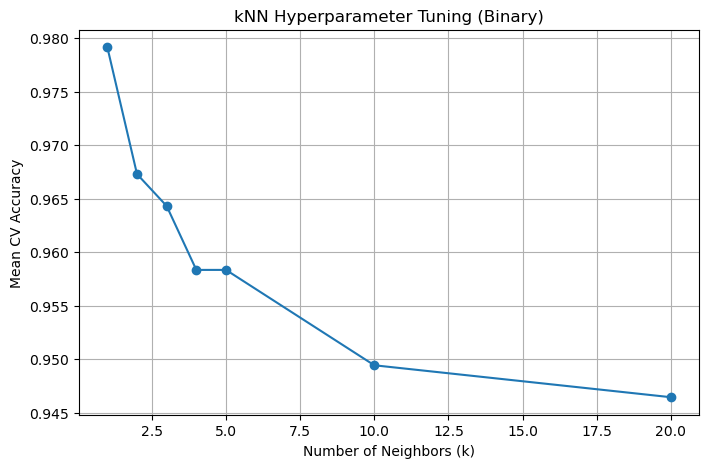

Best k: {'n_neighbors': 1}
Best CV Score: 0.9791483757682178


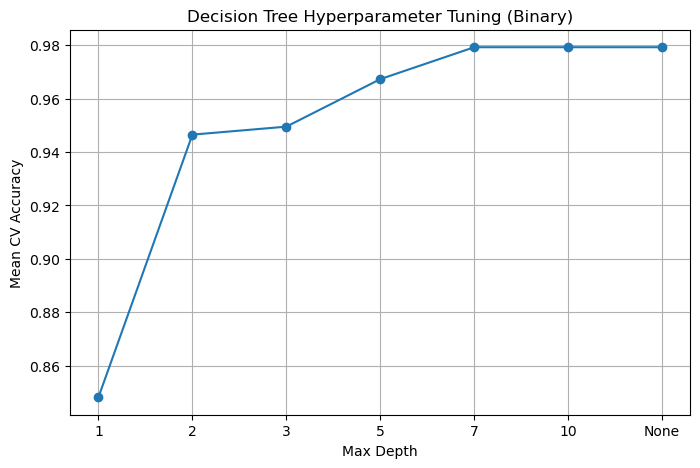

Best depth: {'max_depth': 7}
Best CV Score: 0.9791922739244953


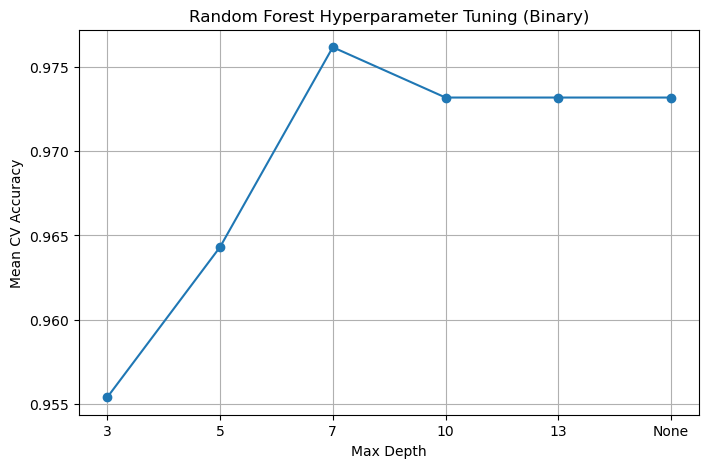

Best RF depth: {'max_depth': 7}
Best CV Score: 0.9761633011413521


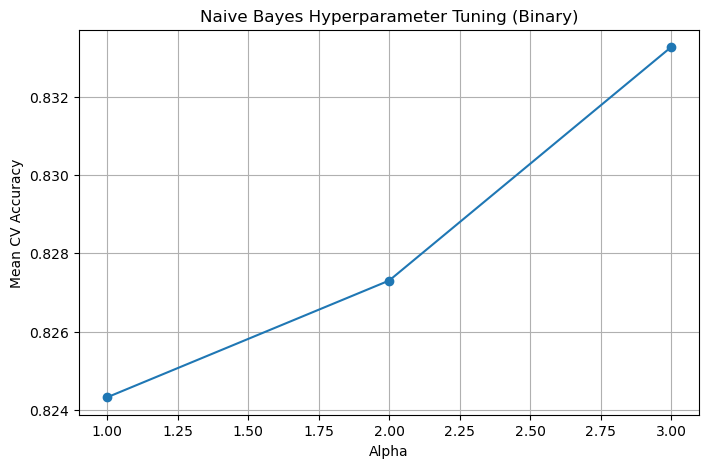

Best alpha: {'alpha': 3}
Best CV Score: 0.8332748024582968


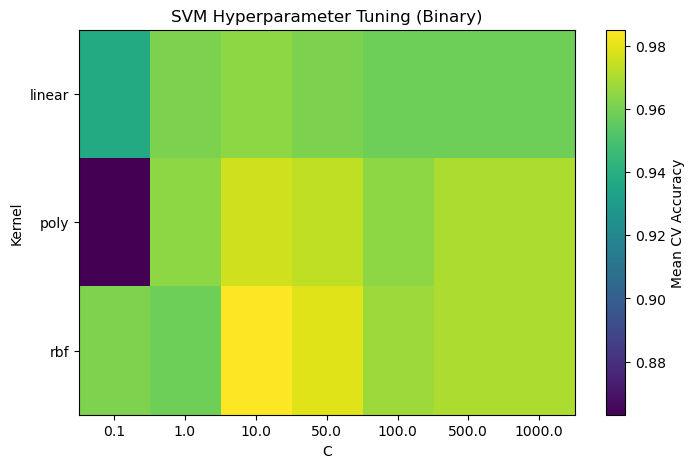

Best SVM params: {'C': 10, 'kernel': 'rbf'}
Best CV Score: 0.9850746268656717


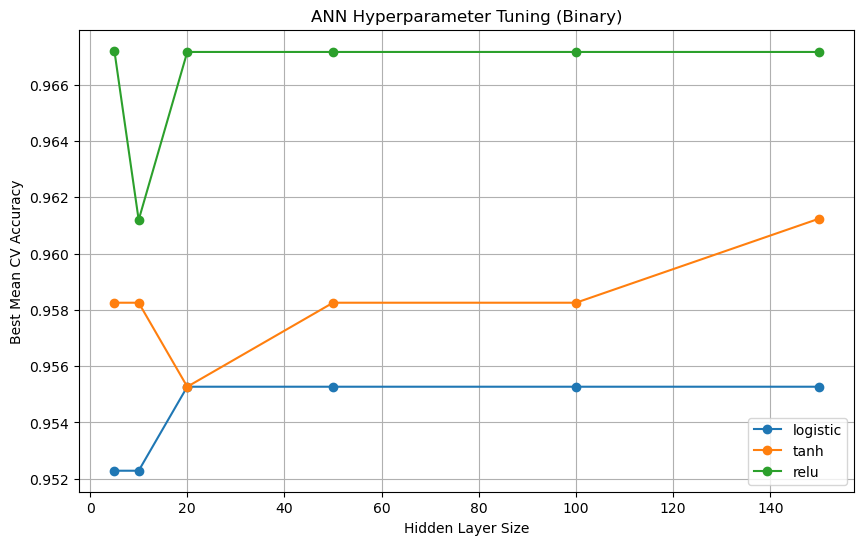

Best ANN params: {'activation': 'relu', 'hidden_layer_sizes': (5,), 'max_iter': 5000}
Best CV Score: 0.9672080772607551


In [82]:
# Binary Classification models

# KNN
knn_results = pd.DataFrame(search_knn.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(knn_results["param_n_neighbors"], knn_results["mean_test_score"], marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean CV Accuracy")
plt.title("kNN Hyperparameter Tuning (Binary)")
plt.grid(True)
plt.show()

print("Best k:", search_knn.best_params_)
print("Best CV Score:", search_knn.best_score_)

# Decision Tree
dt_results = pd.DataFrame(search_dt.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(dt_results["param_max_depth"].astype(str), dt_results["mean_test_score"], marker='o')
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.title("Decision Tree Hyperparameter Tuning (Binary)")
plt.grid(True)
plt.show()

print("Best depth:", search_dt.best_params_)
print("Best CV Score:", search_dt.best_score_)

# RF
rf_results = pd.DataFrame(search_rf.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(rf_results["param_max_depth"].astype(str), rf_results["mean_test_score"], marker='o')
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.title("Random Forest Hyperparameter Tuning (Binary)")
plt.grid(True)
plt.show()

print("Best RF depth:", search_rf.best_params_)
print("Best CV Score:", search_rf.best_score_)

# Naive Bayes
nb_results = pd.DataFrame(search_nb.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(nb_results["param_alpha"], nb_results["mean_test_score"], marker='o')
plt.xlabel("Alpha")
plt.ylabel("Mean CV Accuracy")
plt.title("Naive Bayes Hyperparameter Tuning (Binary)")
plt.grid(True)
plt.show()

print("Best alpha:", search_nb.best_params_)
print("Best CV Score:", search_nb.best_score_)

# SVM (heatmap bc visualizing 3 dimensions)
svm_results = pd.DataFrame(search_svm.cv_results_)

svm_pivot = svm_results.pivot(
    index='param_kernel',
    columns='param_C',
    values='mean_test_score'
)

plt.figure(figsize=(8,5))
plt.imshow(svm_pivot, aspect='auto')
plt.colorbar(label='Mean CV Accuracy')
plt.xticks(range(len(svm_pivot.columns)), svm_pivot.columns)
plt.yticks(range(len(svm_pivot.index)), svm_pivot.index)
plt.xlabel("C")
plt.ylabel("Kernel")
plt.title("SVM Hyperparameter Tuning (Binary)")
plt.show()

print("Best SVM params:", search_svm.best_params_)
print("Best CV Score:", search_svm.best_score_)

# ANN

ann_results = pd.DataFrame(search_ann.cv_results_)

plt.figure(figsize=(10,6))

for activation in ann_results['param_activation'].unique():
    subset = ann_results[ann_results['param_activation'] == activation]
    
    grouped = subset.groupby("param_hidden_layer_sizes")["mean_test_score"].max()
    
    plt.plot(
        [x[0] for x in grouped.index],
        grouped.values,
        marker='o',
        label=activation
    )

plt.xlabel("Hidden Layer Size")
plt.ylabel("Best Mean CV Accuracy")
plt.title("ANN Hyperparameter Tuning (Binary)")
plt.legend()
plt.grid(True)
plt.show()

print("Best ANN params:", search_ann.best_params_)
print("Best CV Score:", search_ann.best_score_)



In [83]:
# Best Hyperparam summary table for binary classification models:
summary = pd.DataFrame({
    "Model": ["kNN", "Decision Tree", "SVM", "Random Forest", "Naive Bayes", "ANN"],
    "Best Params": [
        search_knn.best_params_,
        search_dt.best_params_,
        search_svm.best_params_,
        search_rf.best_params_,
        search_nb.best_params_,
        search_ann.best_params_
    ],
    "Best CV Accuracy": [
        search_knn.best_score_,
        search_dt.best_score_,
        search_svm.best_score_,
        search_rf.best_score_,
        search_nb.best_score_,
        search_ann.best_score_
    ]
})

print(summary)

           Model                                        Best Params  \
0            kNN                                 {'n_neighbors': 1}   
1  Decision Tree                                   {'max_depth': 7}   
2            SVM                         {'C': 10, 'kernel': 'rbf'}   
3  Random Forest                                   {'max_depth': 7}   
4    Naive Bayes                                       {'alpha': 3}   
5            ANN  {'activation': 'relu', 'hidden_layer_sizes': (...   

   Best CV Accuracy  
0          0.979148  
1          0.979192  
2          0.985075  
3          0.976163  
4          0.833275  
5          0.967208  


## Multiclass Classification Models

In [84]:
# Fit a kNN model for multi-class classification using a tuned k value
search_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5)
search_knn.fit(X_train_multi_transformed, quality_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter in

In [85]:
knn_classifier_multi = KNeighborsClassifier(n_neighbors = search_knn.best_params_['n_neighbors'])
knn_classifier_multi.fit(X_train_multi_transformed, quality_train)
quality_pred_knn = knn_classifier_multi.predict(X_test_multi_transformed)
print(knn_classifier_multi.score(X_test_multi_transformed, quality_test))
knn_accuracy_multi = 1 - (np.sum(np.where(quality_pred_knn != quality_test, 1, 0)) / np.size(quality_test))
print(knn_accuracy_multi)

0.9473684210526315
0.9473684210526316


In [86]:
# Fit a decision tree model for multi-class classification using a tuned max depth
search_dt = GridSearchCV(DecisionTreeClassifier(), dt_param_grid, cv=5)
search_dt.fit(X_train_multi_transformed, quality_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter in

In [87]:
dt_classifier_multi = DecisionTreeClassifier(max_depth = search_dt.best_params_['max_depth'])
dt_classifier_multi.fit(X_train_multi_transformed, quality_train)
quality_pred_dt = dt_classifier_multi.predict(X_test_multi_transformed)
print(dt_classifier_multi.score(X_test_multi_transformed, quality_test))
dt_accuracy_multi = 1 - (np.sum(np.where(quality_pred_dt != quality_test, 1, 0)) / np.size(quality_test))
print(dt_accuracy_multi)

1.0
1.0


In [88]:
# Fit a random forest classifier for multi-class classification using a tuned max depth
search_rf = GridSearchCV(RandomForestClassifier(), rf_param_grid, cv=5)
search_rf.fit(X_train_multi_transformed, quality_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter in

In [89]:
rf_classifier_multi = RandomForestClassifier(max_depth = search_rf.best_params_['max_depth'])
rf_classifier_multi.fit(X_train_multi_transformed, quality_train)
quality_pred_rf = rf_classifier_multi.predict(X_test_multi_transformed)
print(rf_classifier_multi.score(X_test_multi_transformed, quality_test))
rf_accuracy_multi = 1 - (np.sum(np.where(quality_pred_rf != quality_test, 1, 0)) / np.size(quality_test))
print(rf_accuracy_multi)

1.0
1.0


In [90]:
# Fit a svm classifier for multi-class classification using a tuned value of C and a kernel selected through 5-fold cross validation
search_svm = GridSearchCV(SVC(), svm_param_grid, cv=5)
search_svm.fit(X_train_multi_transformed, quality_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate pa

In [91]:
svm_classifier_multi = SVC(C = search_svm.best_params_['C'], kernel = search_svm.best_params_['kernel'])
svm_classifier_multi.fit(X_train_multi_transformed, quality_train)
quality_pred_svm = svm_classifier_multi.predict(X_test_multi_transformed)
print(svm_classifier_multi.score(X_test_multi_transformed, quality_test))
svm_accuracy_multi = 1 - (np.sum(np.where(quality_pred_svm != quality_test, 1, 0)) / np.size(quality_test))
print(svm_accuracy_multi)

0.9736842105263158
0.9736842105263158


In [92]:
# Fit a naive Bayes classifier for multi-class classification with a tuned alpha parameter
search_nb = GridSearchCV(CategoricalNB(min_categories=2), nb_param_grid, cv=5)
search_nb.fit(X_train_cat_transformed_multi.toarray(), quality_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CategoricalNB..._categories=2)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter 

In [93]:
nb_classifier_multi = CategoricalNB(min_categories = 2, alpha = search_nb.best_params_['alpha'])
nb_classifier_multi.fit(X_train_cat_transformed_multi.toarray(), quality_train)
quality_pred_nb = nb_classifier_multi.predict(X_test_cat_transformed_multi.toarray())
print(nb_classifier_multi.score(X_test_cat_transformed_multi.toarray(), quality_test))
nb_accuracy_multi = 1 - (np.sum(np.where(quality_pred_nb != quality_test, 1, 0)) / np.size(quality_test))
print(nb_accuracy_multi)

0.7368421052631579
0.736842105263158


In [94]:
# Fit an artificial nerual network with tuned numbers of hidden layer nodes, max iterations, and an activation function selected using 5-fold cross validation
search_ann = GridSearchCV(MLPClassifier(), ann_param_grid, cv=5)
search_ann.fit(X_train_multi_transformed, quality_train)

c:\Users\Tengis\anaconda3\envs\ML\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Tengis\anaconda3\envs\ML\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'activation': ['logistic', 'tanh', ...], 'hidden_layer_sizes': [(5,), (10,), ...], 'max_iter': [2000, 5000, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [95]:
ann_classifier_multi = MLPClassifier(hidden_layer_sizes = search_ann.best_params_['hidden_layer_sizes'], max_iter = search_ann.best_params_['max_iter'], activation = search_ann.best_params_['activation'])
ann_classifier_multi.fit(X_train_multi_transformed, quality_train)
quality_pred_ann = ann_classifier_multi.predict(X_test_multi_transformed)
print(ann_classifier_multi.score(X_test_multi_transformed, quality_test))
ann_accuracy_multi = 1 - (np.sum(np.where(quality_pred_ann != quality_test, 1, 0)) / np.size(quality_test))
print(ann_accuracy_multi)

0.9473684210526315
0.9473684210526316


## K Fold Cross Validation results visualized:

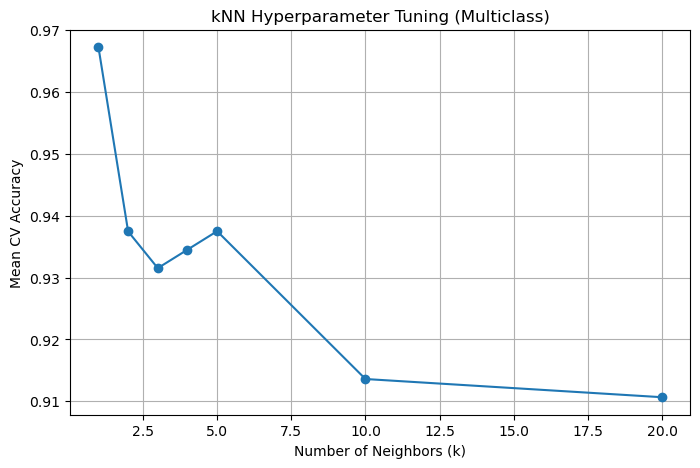

Best kNN params: {'n_neighbors': 1}
Best kNN CV Score: 0.9672080772607551


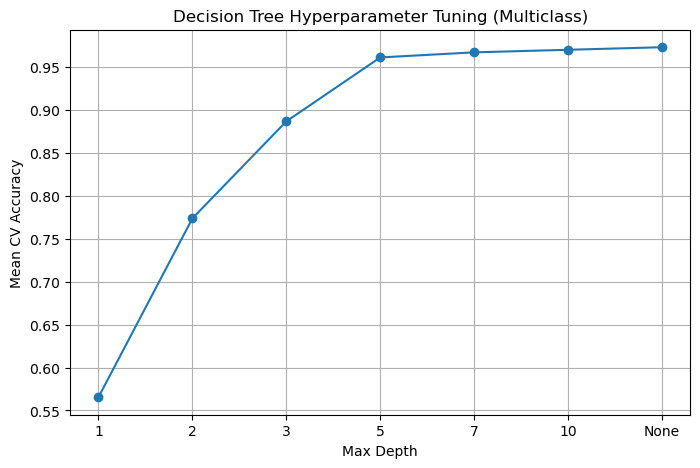

Best DT params: {'max_depth': None}
Best DT CV Score: 0.9732221246707636


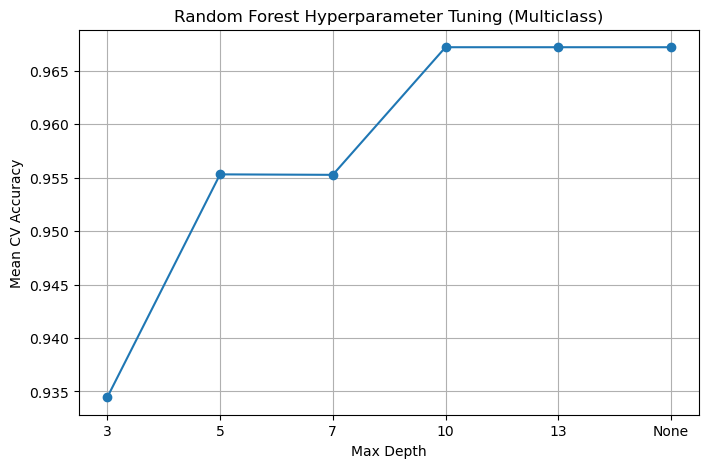

Best RF params: {'max_depth': 10}
Best RF CV Score: 0.9672080772607551


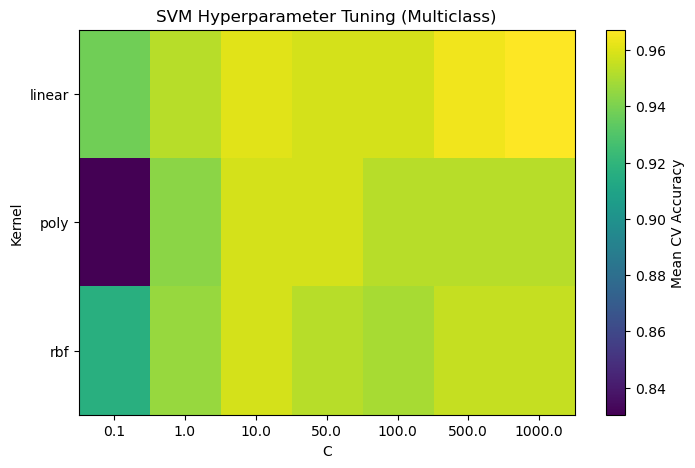

Best SVM params: {'C': 1000, 'kernel': 'linear'}
Best SVM CV Score: 0.9672080772607551


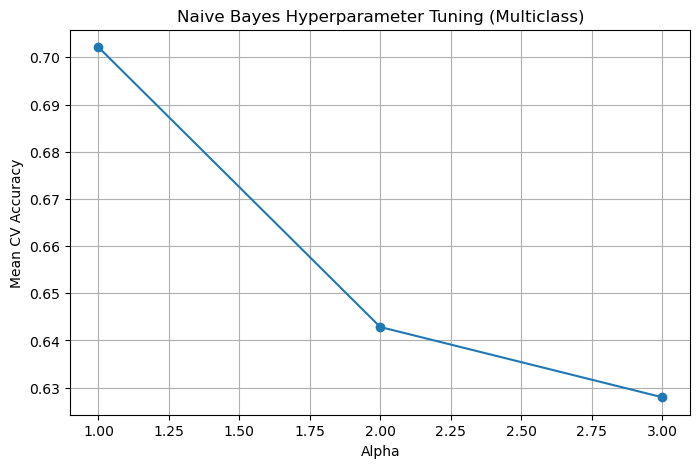

Best NB params: {'alpha': 1}
Best NB CV Score: 0.7021510096575944


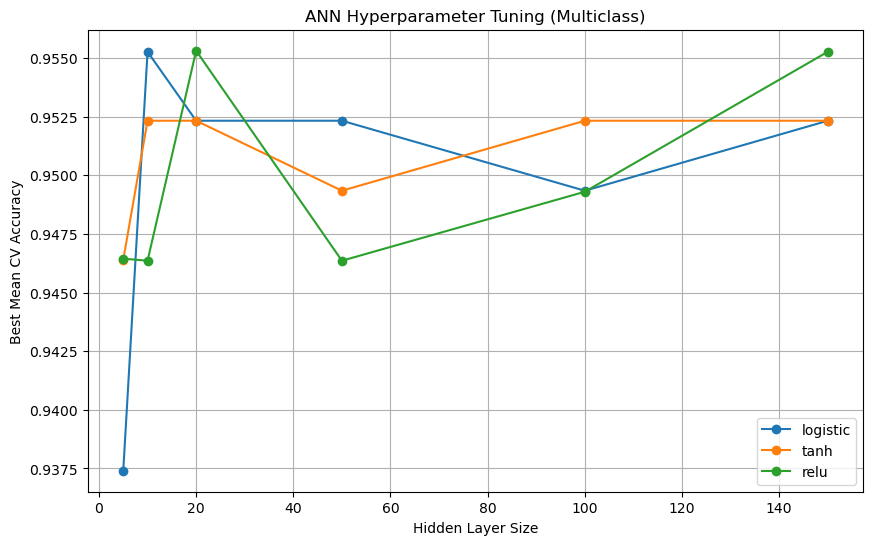

Best ANN params: {'activation': 'relu', 'hidden_layer_sizes': (20,), 'max_iter': 20000}
Best ANN CV Score: 0.9553116769095699


In [96]:
# Multiclass Classification models Kfold Cv plots

#kNN
knn_results_multi = pd.DataFrame(search_knn.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(knn_results_multi["param_n_neighbors"],
         knn_results_multi["mean_test_score"],
         marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean CV Accuracy")
plt.title("kNN Hyperparameter Tuning (Multiclass)")
plt.grid(True)
plt.show()

print("Best kNN params:", search_knn.best_params_)
print("Best kNN CV Score:", search_knn.best_score_)

# decision tree
dt_results_multi = pd.DataFrame(search_dt.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(dt_results_multi["param_max_depth"].astype(str),
         dt_results_multi["mean_test_score"],
         marker='o')
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.title("Decision Tree Hyperparameter Tuning (Multiclass)")
plt.grid(True)
plt.show()

print("Best DT params:", search_dt.best_params_)
print("Best DT CV Score:", search_dt.best_score_)

# RF
rf_results_multi = pd.DataFrame(search_rf.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(rf_results_multi["param_max_depth"].astype(str),
         rf_results_multi["mean_test_score"],
         marker='o')
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.title("Random Forest Hyperparameter Tuning (Multiclass)")
plt.grid(True)
plt.show()

print("Best RF params:", search_rf.best_params_)
print("Best RF CV Score:", search_rf.best_score_)

# SVM
svm_results_multi = pd.DataFrame(search_svm.cv_results_)

svm_pivot_multi = svm_results_multi.pivot(
    index='param_kernel',
    columns='param_C',
    values='mean_test_score'
)

plt.figure(figsize=(8,5))
plt.imshow(svm_pivot_multi, aspect='auto')
plt.colorbar(label='Mean CV Accuracy')
plt.xticks(range(len(svm_pivot_multi.columns)), svm_pivot_multi.columns)
plt.yticks(range(len(svm_pivot_multi.index)), svm_pivot_multi.index)
plt.xlabel("C")
plt.ylabel("Kernel")
plt.title("SVM Hyperparameter Tuning (Multiclass)")
plt.show()

print("Best SVM params:", search_svm.best_params_)
print("Best SVM CV Score:", search_svm.best_score_)

# Naive Bayes
nb_results_multi = pd.DataFrame(search_nb.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(nb_results_multi["param_alpha"],
         nb_results_multi["mean_test_score"],
         marker='o')
plt.xlabel("Alpha")
plt.ylabel("Mean CV Accuracy")
plt.title("Naive Bayes Hyperparameter Tuning (Multiclass)")
plt.grid(True)
plt.show()

print("Best NB params:", search_nb.best_params_)
print("Best NB CV Score:", search_nb.best_score_)

# ANN
ann_results_multi = pd.DataFrame(search_ann.cv_results_)

plt.figure(figsize=(10,6))

for activation in ann_results_multi['param_activation'].unique():
    subset = ann_results_multi[ann_results_multi['param_activation'] == activation]
    
    grouped = subset.groupby("param_hidden_layer_sizes")["mean_test_score"].max()
    
    plt.plot(
        [x[0] for x in grouped.index],
        grouped.values,
        marker='o',
        label=activation
    )

plt.xlabel("Hidden Layer Size")
plt.ylabel("Best Mean CV Accuracy")
plt.title("ANN Hyperparameter Tuning (Multiclass)")
plt.legend()
plt.grid(True)
plt.show()

print("Best ANN params:", search_ann.best_params_)
print("Best ANN CV Score:", search_ann.best_score_)



In [97]:
# Best Hyperparams summary  for Multiclass models:
summary_multi = pd.DataFrame({
    "Model": ["kNN", "Decision Tree", "Random Forest", "SVM", "Naive Bayes", "ANN"],
    "Best Params": [
        search_knn.best_params_,
        search_dt.best_params_,
        search_rf.best_params_,
        search_svm.best_params_,
        search_nb.best_params_,
        search_ann.best_params_
    ],
    "Best CV Accuracy": [
        search_knn.best_score_,
        search_dt.best_score_,
        search_rf.best_score_,
        search_svm.best_score_,
        search_nb.best_score_,
        search_ann.best_score_
    ]
})

print(summary_multi)


           Model                                        Best Params  \
0            kNN                                 {'n_neighbors': 1}   
1  Decision Tree                                {'max_depth': None}   
2  Random Forest                                  {'max_depth': 10}   
3            SVM                    {'C': 1000, 'kernel': 'linear'}   
4    Naive Bayes                                       {'alpha': 1}   
5            ANN  {'activation': 'relu', 'hidden_layer_sizes': (...   

   Best CV Accuracy  
0          0.967208  
1          0.973222  
2          0.967208  
3          0.967208  
4          0.702151  
5          0.955312  
